# **CMSC 320 - FINAL PROJECT**

In [23]:
#imports
import pandas as pd
import string
import math
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd




**PART 1 - DATA PROCESSING**

We are using Earthquake data from the USGS earthquake data website.  This data is from June 1st, 2005 to September 27th, 2012. It includes not only earthquake data but data involving Volcano Eruption and Landsides all of which has been reviewd in the context of Earthquakes.

In [24]:
earthquakes_df = pd.read_csv("Earthquakes.csv")
earthquakes_df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2005-06-01T12:24:21.490Z,18.4620,-68.7530,148.1,4.2,mb,47.0,47.7,NaN,NaN,...,2014-11-07T01:26:03.100Z,"9 km WNW of San Rafael del Yuma, Dominican Rep...",earthquake,NaN,NaN,NaN,11.0,reviewed,rspr,us
1,2005-06-01T21:55:04.580Z,17.0910,-46.4740,10.0,5.0,mwc,241.0,44.7,NaN,0.72,...,2025-12-19T23:08:34.930Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
2,2005-06-01T21:58:40.450Z,17.0670,-46.4480,10.0,4.8,mb,81.0,46.4,NaN,0.69,...,2014-11-07T01:26:04.203Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,30.0,reviewed,us,us
3,2005-06-02T04:50:07.800Z,19.4800,-103.5720,7.0,4.1,md,6.0,104.8,NaN,NaN,...,2014-11-07T01:26:04.430Z,"5 km NNW of Cofradía, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,unm,unm
4,2005-06-02T09:29:38.580Z,26.4510,-44.7070,10.0,4.7,mb,21.0,128.4,NaN,1.16,...,2014-11-07T01:26:04.558Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,12.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2012-09-26T11:37:27.550Z,10.2180,-85.1100,57.1,4.2,mb,31.0,196.4,NaN,0.86,...,2014-11-07T01:48:55.204Z,"17 km WSW of Juntas, Costa Rica",earthquake,NaN,5.3,NaN,13.0,reviewed,us,us
15996,2012-09-26T18:15:22.200Z,14.8520,-61.2440,169.6,4.3,md,32.0,136.9,NaN,NaN,...,2014-11-07T01:48:55.280Z,"13 km W of Basse-Pointe, Martinique",earthquake,NaN,NaN,NaN,NaN,reviewed,trn,trn
15997,2012-09-26T22:23:23.940Z,26.8630,-44.2400,10.0,4.4,mb,40.0,88.6,NaN,1.04,...,2014-11-07T01:48:55.300Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,10.0,reviewed,us,us
15998,2012-09-27T03:03:41.090Z,9.8210,-85.5690,36.7,4.4,mb,60.0,139.7,NaN,1.36,...,2014-11-07T01:48:55.505Z,"8 km SW of Sámara, Costa Rica",earthquake,NaN,9.5,NaN,32.0,reviewed,us,us


Information about the dataset before any modifications take place

In [25]:
print(f"df.shape: {earthquakes_df.shape}")
earthquakes_df.shape
print("df.describe(): ")
display(earthquakes_df.describe())
print("df.info(): ")
earthquakes_df.info()



df.shape: (16000, 22)
df.describe(): 


,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,16000.000000,16000.000000,16000.000000,16000.00000,14720.000000,14717.000000,1490.000000,7664.000000,1513.000000,4770.000000,1176.000000,6173.000000
mean,27.611573,-104.703152,38.187911,4.10787,47.583628,168.173160,0.278961,0.850562,1.483323,14.140468,0.191622,51.673092
std,16.763399,31.873068,43.143381,0.49540,77.578092,79.883874,0.357982,0.889954,5.029209,155.091728,0.157575,84.415456
min,7.959000,-171.562000,-2.285000,3.50000,0.000000,11.900000,0.001802,0.009800,0.080000,0.000000,0.000000,0.000000
25%,15.886000,-120.798542,10.000000,3.70000,8.000000,107.000000,0.054320,0.570000,0.300000,0.500000,0.134000,5.000000
50%,18.629000,-98.362000,19.000000,4.00000,18.000000,170.200000,0.166600,0.920000,0.580000,4.025000,0.163000,15.000000
75%,40.308958,-87.848000,51.700000,4.40000,49.000000,219.800000,0.392775,1.150000,1.630000,12.000000,0.200000,50.000000
max,72.852000,-36.609000,294.900000,7.60000,857.000000,358.300000,5.654000,69.320000,99.000000,9117.600000,1.680000,438.000000


df.info(): 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             16000 non-null  object 
 1   latitude         16000 non-null  float64
 2   longitude        16000 non-null  float64
 3   depth            16000 non-null  float64
 4   mag              16000 non-null  float64
 5   magType          16000 non-null  object 
 6   nst              14720 non-null  float64
 7   gap              14717 non-null  float64
 8   dmin             1490 non-null   float64
 9   rms              7664 non-null   float64
 10  net              16000 non-null  object 
 11  id               16000 non-null  object 
 12  updated          16000 non-null  object 
 13  place            16000 non-null  object 
 14  type             16000 non-null  object 
 15  horizontalError  1513 non-null   float64
 16  depthError       4770 non-null   float64
 17  

Parse data: Sort by magnitude

In [26]:
#sort by mag highest to smallest
earthquakes_df = earthquakes_df.sort_values(by=['mag'], ascending=False).reset_index(drop='True')

#this line below is to check if there was mag error, there is, maybe we could use it
#earthquakes_df = earthquakes_df.dropna(subset=['magError'])

#date only column, in datetime (remove .dt.date to get full date and time in datetime format)
date = pd.to_datetime(earthquakes_df['time']).dt.date
earthquakes_df.insert(0, 'date', date)
display(earthquakes_df)

,date,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2012-09-05,2012-09-05T14:42:07.800Z,10.085,-85.315,35.0,7.6,mww,703.0,34.3,NaN,...,2025-01-03T07:43:01.170Z,"11 km ENE of Hojancha, Costa Rica",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
1,2012-03-20,2012-03-20T18:02:47.440Z,16.493,-98.231,20.0,7.4,mww,672.0,37.9,NaN,...,2022-05-03T15:34:09.063Z,"6 km E of Santiago Llano Grande, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
2,2007-11-29,2007-11-29T19:00:20.420Z,14.944,-61.274,156.0,7.4,mwb,663.0,13.4,NaN,...,2022-07-13T02:37:48.411Z,"18 km WNW of Basse-Pointe, Martinique",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
3,2009-05-28,2009-05-28T08:24:46.560Z,16.731,-86.217,19.0,7.3,mwc,464.0,27.2,NaN,...,2025-07-03T19:11:11.454Z,"46 km NW of Guanaja, Honduras",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gcmt
4,2012-08-27,2012-08-27T04:37:19.430Z,12.139,-88.590,28.0,7.3,mww,417.0,37.0,NaN,...,2022-05-03T15:48:15.643Z,"126 km S of Puerto El Triunfo, El Salvador",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2010-07-22,2010-07-22T17:50:56.850Z,52.615,-169.359,14.2,3.5,ml,17.0,210.7,NaN,...,2018-07-06T21:13:23.583Z,"Fox Islands, Aleutian Islands, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,aeic,aeic
15996,2010-07-22,2010-07-22T12:51:55.770Z,52.723,-169.719,13.5,3.5,ml,20.0,196.8,NaN,...,2018-07-06T21:13:09.439Z,"62 km WSW of Nikolski, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,aeic,aeic
15997,2010-07-22,2010-07-22T09:47:06.070Z,52.609,-169.281,15.5,3.5,ml,27.0,140.9,NaN,...,2018-07-06T21:13:04.124Z,"46 km SW of Nikolski, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,aeic,aeic
15998,2010-07-21,2010-07-21T23:34:15.150Z,52.700,-169.113,5.4,3.5,ml,21.0,140.9,NaN,...,2018-07-06T21:12:09.310Z,"31 km SSW of Nikolski, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,aeic,aeic


**PART 2**

### Method 1: Frequency of Earthquakes Based on Geographical Region using Chi Square Test


We will first examine the frequency of earthquakes based off of geographical region. To better visualize the correlation between how often the earthquakes happen and which locations get the most number of earthquakes, we will use a bar chart and a pie chart. First, we want to see how frequent are the earthquakes in the locations in our database. We notice that most of the locations have only 1 earthquake, with the graph being extremely right skewed that is almost imposible to be seen on the graph. From this first graph we understand that most of the locations in our data base have less than 10 earthquakes.

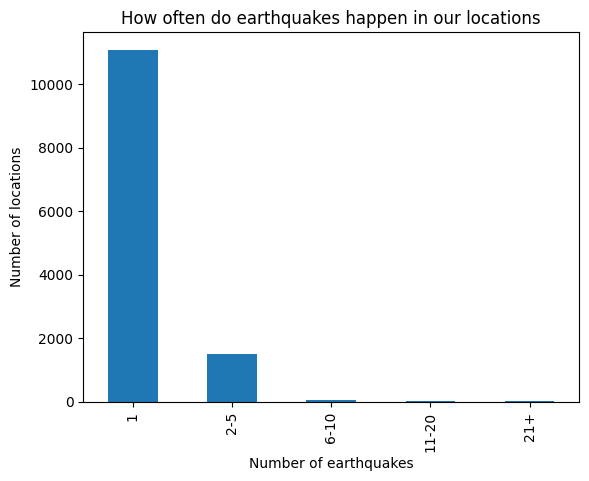

In [27]:
place_types = earthquakes_df['place'].value_counts()
#print(place_types.count())

bins = [0,1, 5, 10, 20, float('inf')]
labels = ['1','2-5','6-10', '11-20', '21+']

binned = pd.cut(place_types, bins = bins, labels=labels)
binned_occurences = binned.value_counts().sort_index()

binned_occurences.plot(kind='bar')
plt.title('How often do earthquakes happen in our locations')
plt.xlabel('Number of earthquakes')
plt.ylabel('Number of locations')

plt.show()

There is a lot of locations that only experience one earthquake. We wanted to see exactly which locations are prone to having more earthquakes and their exact number of earthquakes. More specifically, we wanted to take a closer look at the locations that have more than 10 earthquakes.

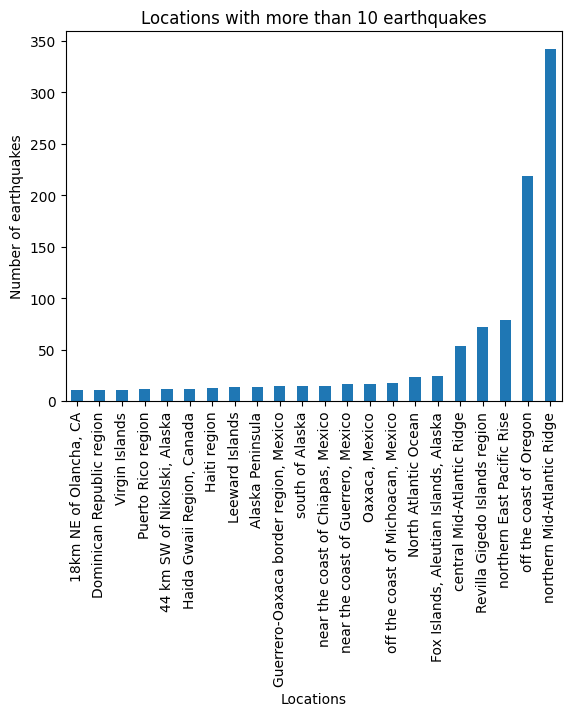

In [28]:
place_types_more_than_10_occurences = place_types[place_types > 10]

place_types_more_than_10_occurences.sort_values().plot(kind='bar')

plt.title("Locations with more than 10 earthquakes")
plt.ylabel('Number of earthquakes')
plt.xlabel('Locations')
plt.show()

Notice that there are 2 locations with an astonishing amount of earthquakes, more than 100. These 2 locations are the outliers that are skewing the graph. This made us wonder what is the distribution of the frequency of earthquakes.

---
---
---

Among out dataset, we wondered what is the percentage of locations that suffered 1 earthquake, between 2 and 10, and finally, more than 11. For this question we used the pie chart which perfectly shows that almost 88% of the locations have suffered only 1 earthquake, while 0.174% have suffered more than 11 earthquakes.

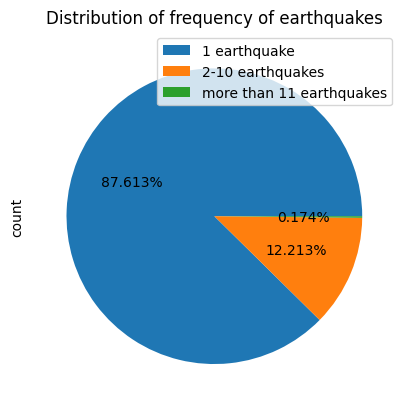

In [29]:
bins = [0,1, 10, float('inf')]
labels = ['1','2-10', '11+']

binned = pd.cut(place_types, bins = bins, labels=labels)
binned_occurences = binned.value_counts().sort_index()


legend=['1 earthquake', '2-10 earthquakes', 'more than 11 earthquakes']
myexplode=[0, 0, 0.7]
binned_occurences.plot(kind='pie', labels=None, autopct='%1.3f%%')
plt.title('Distribution of frequency of earthquakes')
plt.legend(legend)
plt.show()

This brought us to our next question, are certain areas more prone to earthquakes with higher or lower frequency? We want to see the relationship and the ratio between the frequency of the earthquakes and the areas where these earthquakes happened. We will be using the Chi-Square Test for Independence and our Null Hypothesis is that there is no relation.

In [30]:
#place_types = earthquakes_df['place'].value_counts()

my_places = place_types

my_places = my_places.reset_index()
my_places.columns = ['place', 'count']

#calculate the average latitude for each place
latitude_table = earthquakes_df.groupby('place', as_index=False)['latitude'].mean()

earthquake_dataframe = pd.merge(
    my_places,
    latitude_table,
    on='place',
    how='inner'
)

#this is variable 1
bins = [0, 1, 10, float('inf')]
labels = ['1 earthquake', '2 to 10 earthquakes', 'more than 10 earthquakes']
earthquake_dataframe['count category'] = pd.cut(earthquake_dataframe['count'], bins = bins, labels=labels)

#this is variable 2
bins = [0, 30, 60, 90]
labels = ['Low Latitude', 'Mid Latitude', 'High Latitude']
earthquake_dataframe['region category'] = pd.cut(earthquake_dataframe['latitude'], bins = bins, labels=labels)


#i need contingency table
contingency_table = pd.crosstab(earthquake_dataframe['count category'], earthquake_dataframe['region category'])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(contingency_table)

print("\np-value:", p_value)

if p_value <= 0.05:
    print('\nDependent (reject H0)')
else:
    print('\nIndependent (H0 holds true)')

region category           Low Latitude  Mid Latitude  High Latitude
count category                                                     
1 earthquake                      7726          2614            743
2 to 10 earthquakes                849           636             60
more than 10 earthquakes            15             7              0

p-value: 1.6064832498422369e-47

Dependent (reject H0)


The Chi-square test shows that there is a relation between the lower, middle, higher part of the locations in our dataframe, and the earthquake frequency. From the table we can see that locations with only one earthquake are predominantly in the lower region, and the earthquakes are not evenly distributed across lower, middle and higher regions.

### Method 2: Magnitude vs Depth using Pearson Correlation

Earlier we found that the Low Latitude region contained the greatest number of earthquake locations across all frequency categories. We will now use this region to investigate whether earthquake magnitude and depth are correlated.

Pearson correlation (Magnitude vs. Depth): -0.06725108164089767


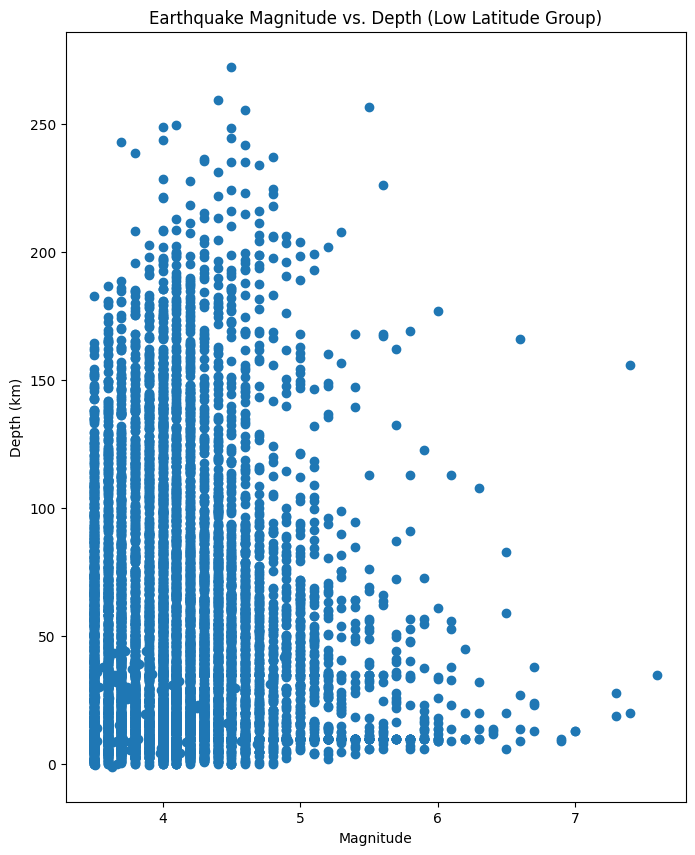

In [31]:
south_locations = earthquake_dataframe[earthquake_dataframe['region category'] == 'Low Latitude']['place']

region = earthquakes_df[earthquakes_df['place'].isin(south_locations)].copy()

rvalue = region['mag'].corr(region['depth'])
print(f"Pearson correlation (Magnitude vs. Depth): {rvalue}")

plt.figure(figsize=(8, 10))
plt.scatter(region['mag'], region['depth'])
plt.title("Earthquake Magnitude vs. Depth (Low Latitude Group)")
plt.xlabel("Magnitude")
plt.ylabel("Depth (km)")
plt.show()



Now looking at the data below looks superoverwhelming but thats because there is a lot of earthquakes that happened in a Low Latitude region as mentioned before. Looking at the graphy it cane be said that after a mag magnitude of 5.5 the depth of a earthquake is likely to be smaller than 175km.

There is a weak negative correlation but because there is so much data, we need to break some of this information down. We are going to still look at the south group. But we are going to visualize how many earthquakes there are by date.

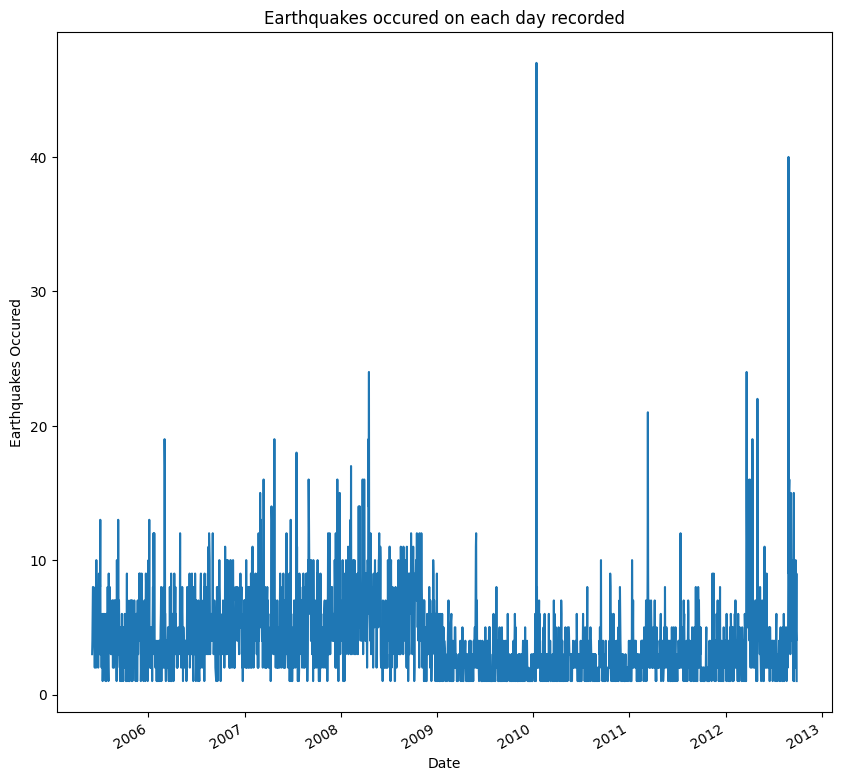

In [32]:
region['date'] = pd.to_datetime(region['date'])
plt.figure(figsize=(10, 10))
region['date'].value_counts().sort_index().plot()
plt.xlabel("Date")
plt.ylabel("Earthquakes Occured")
plt.title("Earthquakes occured on each day recorded")
plt.show()

We can see a huge spikes of earthquakes in around 2008, 2010, and 2012. But we are going to break this down a little further, and see the break down in just 2010 and see if there is more of a corrleation between Depth and magnitude since there will be less data points.

Pearson r value for 2010 for depth and mag is: -0.024524940684534084


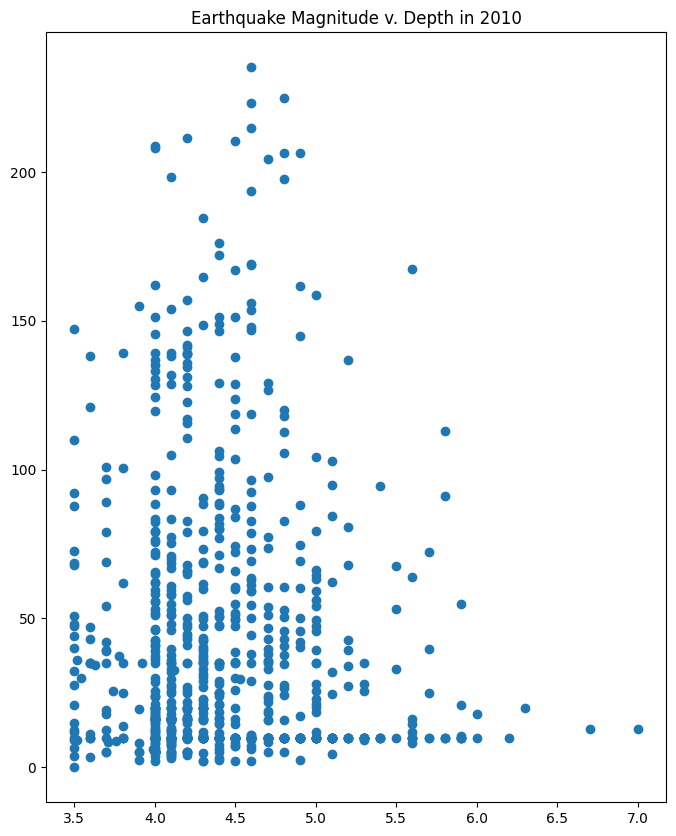

In [33]:
region['year'] = pd.to_datetime(region['date']).dt.year
south_earthquakes = region.groupby(region['year'])
year = south_earthquakes.get_group(2010)

#then find magnitude v depth
rvalue2010 = year['depth'].corr(year['mag'])
print(f"Pearson r value for 2010 for depth and mag is: {rvalue2010}")
plt.figure(figsize=(8, 10))
plt.scatter(year['mag'], year['depth'])
plt.title("Earthquake Magnitude v. Depth in 2010")
plt.show()

There is still a lot of data points and the R-value is still small but looking at the second graph it can be seen more clearly that in 2010, when the magnitude was larger than 5.5 that there is negative corrleation to the depth of the earthquake. The higher the magnitude leads to much smaller depth.

**NOTE FOR GROUP MATES:**
what I did is I switched the methods to make it flow a little better. So Ana's analysis was about frequency in each region, and it concluded that the South divide of the globe contained a higher freq of earthquakes. i didn't edit her code. in order to make it flow like a story, i edited Natalie's method to examine the correlation of mag vs depth in that Southern region that had a higher frequency. I'm not sure how effective this is, i just wanted to relate the themes of our methods together. I wonder if in Natalie's method, we should find correlation between mag and depth for all 3 regions instead of zooming in on just one?

### Method 3: Comparison of Earthquake Characteristics Across Latitude Regions using ANOVA testing

We have three divides of the regions: Low Latitude, Mid Latitude, and High Latitude

We know want to examine and compare the average magnitude and depth of the recorded earthquakes between each divide. Earlier we observed that the Low Latitude region contains the largest number of earthquake locations across all frequency categories, followed by the Mid Latitude region, while the High Latitude region has the fewest. Let's perform Anova to examine the average depths across the different regions:

In [34]:
#divide the dataframe into the regions
groups = earthquake_dataframe.groupby("region category",observed=False)

low = groups.get_group("Low Latitude")
mid = groups.get_group("Mid Latitude")
high = groups.get_group("High Latitude")

#grab the places within each region from the original dataframe
low_places = low["place"]
low_earthquakes = earthquakes_df[earthquakes_df["place"].isin(low_places)]

mid_places = mid["place"]
mid_earthquakes = earthquakes_df[earthquakes_df["place"].isin(mid_places)]

high_places = high["place"]
high_earthquakes = earthquakes_df[earthquakes_df["place"].isin(high_places)]

#print the avg depths
print("Mean depth of lower lat regions:",low_earthquakes['depth'].mean())
print("Mean depth of middle lat regions:", mid_earthquakes['depth'].mean())
print("Mean depth of higher lat regions:", high_earthquakes['depth'].mean())

#perform the ANOVA test
f_stat, p_value = stats.f_oneway(low_earthquakes["depth"].dropna(), mid_earthquakes["depth"].dropna(), high_earthquakes["depth"].dropna())
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value <= 0.05:
    print("Reject H0: at least one region has a significantly different mean depth.")
else:
    print("Fail to reject H0: no significant difference in mean depth across regions.")



Mean depth of lower lat regions: 45.99923577779902
Mean depth of middle lat regions: 19.990505821474773
Mean depth of higher lat regions: 41.178959025470654
F-statistic: 632.4297627857349
p-value: 4.542631155118132e-265
Reject H0: at least one region has a significantly different mean depth.


We see that between the three regions, there is at least one region with a significantly different mean depth. Let's dig down further and see exactly which region is significantly different using Tukey's HSD test:

In [35]:
#because depth and region category are from two different dataframes, we merge them by stacking each column
tukey_df = pd.DataFrame({
    "depth": pd.concat([low_earthquakes["depth"],mid_earthquakes["depth"],high_earthquakes["depth"]], ignore_index=True),
    "region category": (["Low Latitude"] * len(low_earthquakes) + ["Mid Latitude"] * len(mid_earthquakes) + ["High Latitude"] * len(high_earthquakes))
})

tukey = pairwise_tukeyhsd(endog=tukey_df["depth"], groups=tukey_df["region category"], alpha=0.05)

print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1       group2    meandiff p-adj   lower    upper   reject
-------------------------------------------------------------------
High Latitude Low Latitude   4.8203 0.0024   1.4435    8.197   True
High Latitude Mid Latitude -21.1885    0.0 -24.7296 -17.6473   True
 Low Latitude Mid Latitude -26.0087    0.0 -27.7262 -24.2912   True
-------------------------------------------------------------------


Here we can see that all three regions have significally different mean depths from the others. This suggests a strong relationship between latitude region and earthquake depth.

Let's plot the data to observe other statistical characteristics:

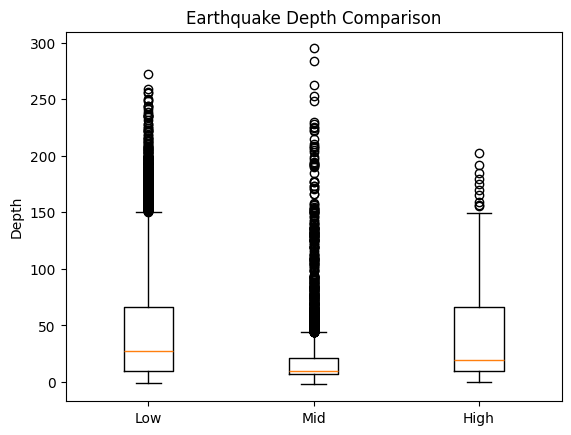

In [36]:
data = [
    low_earthquakes["depth"],
    mid_earthquakes["depth"],
    high_earthquakes["depth"]
]

plt.boxplot(data, tick_labels=["Low", "Mid", "High"])
plt.title("Earthquake Depth Comparison")
plt.ylabel("Depth")
plt.show()

The box plot shows that the three latitude regions have different distributions of earthquake depths. The Low Latitude region has the highest median depth, the Mid Latitude region has the lowest median depth, and the High Latitude region is in between those two. These visual differences are consistent with our ANOVA and Tukey HSD results.One thing to note is that there are so many outliers for the earthquake depth.

Now let's do the same analysis for magnitude:

In [37]:
#print the avg mags
print("Mean magnitude of lower lat regions:",low_earthquakes['mag'].mean())
print("Mean magnitude of middle lat regions:", mid_earthquakes['mag'].mean())
print("Mean magnitude of higher lat regions:", high_earthquakes['mag'].mean())

#perform the ANOVA test
f_stat, p_value = stats.f_oneway(low_earthquakes["mag"].dropna(), mid_earthquakes["mag"].dropna(), high_earthquakes["mag"].dropna())
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value <= 0.05:
    print("Reject H0: at least one region has a significantly different mean magnitude.")
else:
    print("Fail to reject H0: no significant difference in mean magnitude across regions.")

Mean magnitude of lower lat regions: 4.153935366669854
Mean magnitude of middle lat regions: 4.033615782664942
Mean magnitude of higher lat regions: 3.955703211517165
F-statistic: 142.38625323109173
p-value: 5.0862094704650455e-62
Reject H0: at least one region has a significantly different mean magnitude.


Here we see that at least one region has a significantly different mean magnitude. Let's dig down even further and perform Tukey's HSD test for this result as well:

In [38]:
#because mag and region category are from two different dataframes, we merge our two necessary columns by stacking each column
tukey_df = pd.DataFrame({
    "mag": pd.concat([low_earthquakes["mag"],mid_earthquakes["mag"],high_earthquakes["mag"]], ignore_index=True),
    "region category": (["Low Latitude"] * len(low_earthquakes) + ["Mid Latitude"] * len(mid_earthquakes) + ["High Latitude"] * len(high_earthquakes))
})

tukey = pairwise_tukeyhsd(endog=tukey_df["mag"], groups=tukey_df["region category"], alpha=0.05)

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1       group2    meandiff p-adj  lower  upper  reject
---------------------------------------------------------------
High Latitude Low Latitude   0.1982   0.0  0.1583 0.2382   True
High Latitude Mid Latitude   0.0779   0.0   0.036 0.1198   True
 Low Latitude Mid Latitude  -0.1203   0.0 -0.1406   -0.1   True
---------------------------------------------------------------


Here we can see that all three regions have significantly different mean magnitudes from one another. This indicates that earthquake magnitude varies significantly across latitude regions, which is the same conclusion we derived for the earthquake depth.

Let's plot for magnitude:

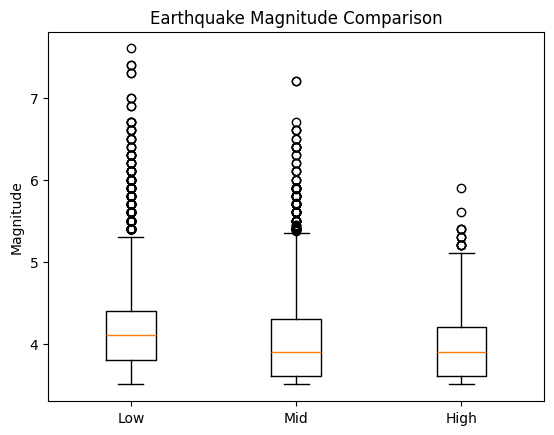

In [39]:
data = [
    low_earthquakes["mag"],
    mid_earthquakes["mag"],
    high_earthquakes["mag"]
]

plt.boxplot(data, tick_labels=["Low", "Mid", "High"])
plt.title("Earthquake Magnitude Comparison")
plt.ylabel("Magnitude")
plt.show()

Here we see that the Low Latitude region has the highest median earthquake magnitude, while the Mid Latitude and High Latitude regions have slightly lower and more similar medians. This is still consistent with the Anova and Tukey HSD test results. Notice that there are fewer outliers in the magnitude data as well.